In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras.backend as K

2025-03-26 16:38:13.884810: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-26 16:38:14.021061: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-26 16:38:14.062420: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-26 16:38:14.799214: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [2]:
balanced_datapath = "../../localised_balanced/"
imbalanced_datapath = "../../localised_reduced/"

base_model_path = "../models/mobilenet-localised-100.h5"
augmented_model_path = "../models/mobilenet_localised_augmented.h5"

In [3]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [4]:
base_model = tf.keras.models.load_model(base_model_path, custom_objects={"f1_score": f1_score})
augmented_model = tf.keras.models.load_model(augmented_model_path, custom_objects={"f1_score": f1_score})

test_datagen = ImageDataGenerator(rescale = 1./255)
balanced_dataset = test_datagen.flow_from_directory(directory = balanced_datapath + "test",
                                                  target_size = (224,224),
                                                  class_mode = 'categorical'
                                                  )
imbalanced_dataset = test_datagen.flow_from_directory(directory = imbalanced_datapath + "test",
                                                  target_size = (224,224),
                                                  class_mode = 'categorical'
                                                  )

2025-03-26 16:38:15.974010: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-26 16:38:16.104119: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20750 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


Found 465 images belonging to 3 classes.
Found 739 images belonging to 3 classes.


In [5]:
print("Base model & balanced dataset")
base_balanced_scores = base_model.evaluate(balanced_dataset)
print("Augmented model & balanced dataset")
base_balanced_scores = augmented_model.evaluate(balanced_dataset)
print("Base model & imbalanced dataset")
base_balanced_scores = base_model.evaluate(imbalanced_dataset)
print("Augmented model & imbalanced dataset")
base_balanced_scores = augmented_model.evaluate(imbalanced_dataset)

Base model & balanced dataset
 3/15 [=====>........................] - ETA: 0s - loss: 0.5430 - auc: 0.9300 - accuracy: 0.8229 - precision: 0.8571 - recall: 0.7500 - f1_score: 0.7992 

2025-03-26 16:38:21.762643: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8900
2025-03-26 16:38:21.834495: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


15/15 [==============================] - 2s 35ms/step - loss: 0.6261 - auc: 0.8956 - accuracy: 0.7613 - precision: 0.7937 - recall: 0.7032 - f1_score: 0.7418
Augmented model & balanced dataset
15/15 [==============================] - 2s 35ms/step - loss: 0.7446 - auc: 0.8475 - accuracy: 0.6323 - precision: 0.6754 - recall: 0.6086 - f1_score: 0.6438
Base model & imbalanced dataset
24/24 [==============================] - 1s 35ms/step - loss: 0.6327 - auc: 0.8914 - accuracy: 0.7307 - precision: 0.7620 - recall: 0.6847 - f1_score: 0.7306
Augmented model & imbalanced dataset
24/24 [==============================] - 1s 37ms/step - loss: 0.6729 - auc: 0.8758 - accuracy: 0.6847 - precision: 0.7175 - recall: 0.6495 - f1_score: 0.6808


24/24 [==============================] - 1s 39ms/step


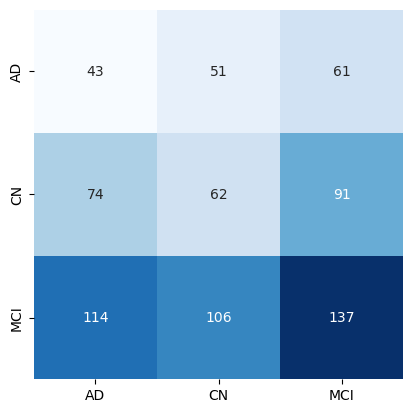

In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import collections

dataset = imbalanced_dataset
model = base_model

class_indices = dataset.class_indices

true_classes = dataset.classes
preds = model.predict(dataset)
pred_classes = np.argmax(preds, axis=1)

# Get the names of the ten classes
class_names = imbalanced_dataset.class_indices.keys()
# true_classes = np.where(true_classes==1, 2, np.where(true_classes==2, 1, true_classes))
# pred_classes = np.where(pred_classes==1, 2, np.where(pred_classes==2, 1, pred_classes))
# new_names = ["CN", "MCI", "AD"]

# print(true_classes)
# print(pred_classes)

def plot_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names
    )

plt.figure()
plot_heatmap(true_classes, pred_classes)    

plt.show()